# Capstone: OOS RMSE against Feature Count and Regularization Strength

## Introduction

Every notebook in this project asked some version of the same question.
Does adding more data or more model flexibility actually help? SARIMA
(01) and SARIMAX (02) answered it with a qualified yes, for one
parsimonious, well-chosen exogenous variable. Layers 1 and 2 (03-04)
answered it piecemeal for a larger, more generic feature set, mostly
landing on not yet. This notebook asks the question
directly and exhaustively. Hold everything else
fixed, vary only feature count and regularization strength, and look at
the resulting error surface.

Designed to keep this a controlled experiment: Layers 1 and 2 and the
simplification test are not directly comparable to each other, because
they differ in sample size and feature count at once. BDRY and sentiment
both capped history around 2018. This notebook
instead fixes the dataset to Layer 2's, 96 rows and the same 36-month
test window throughout, and adds features one at a time in the order
SHAP ranked them for the Layer 2 GBM. Feature count is then the only
thing moving on that axis. Ridge's alpha is gridded from 0.1 to 1000 at
each step.

This is descriptive, not a hyperparameter search. The full 8 by 10 grid,
80 cells, is reported in full. No single best cell is proposed as a
deployable model. Picking the best of 80 based on test-window
performance would be a test-set-tuning mistake. With 80 comparisons against the same
36 points, some cell looking good is partly expected by chance. The
shape of the surface is the trustworthy part, not any single minimum.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

surface = pd.read_csv("../data/capstone_surface.csv")
surface.head()

,n_features,alpha,rmse
0,1,0.1,2.927768e+09
1,1,1.0,2.969179e+09
2,1,3.0,3.065858e+09
3,1,10.0,3.432108e+09
4,1,30.0,4.453503e+09


## The surface

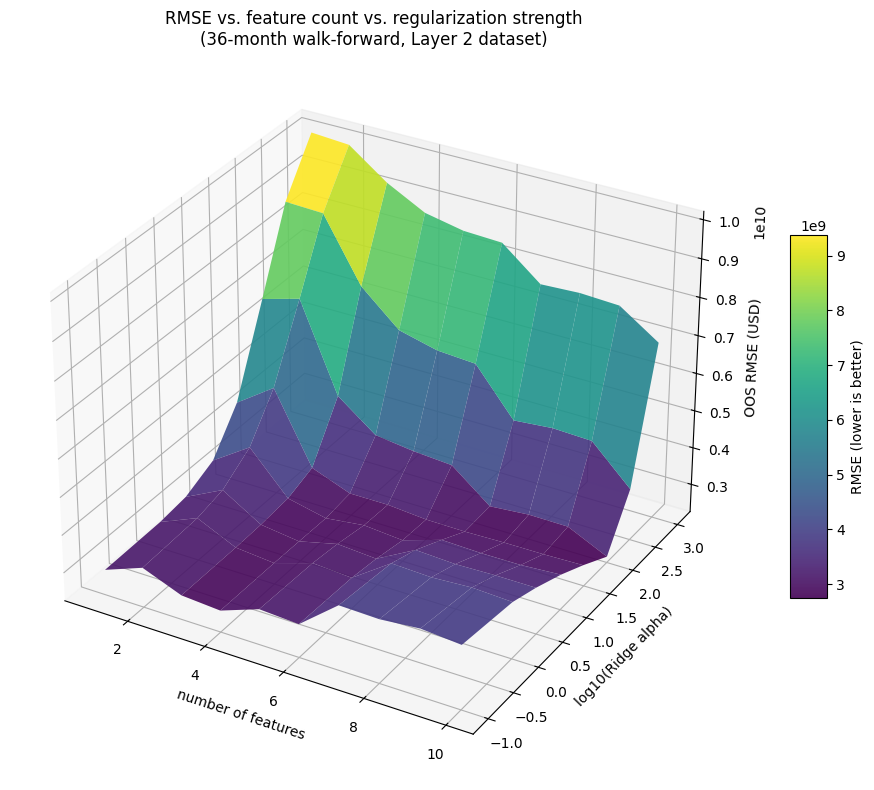

In [2]:
pivot = surface.pivot(index="alpha", columns="n_features", values="rmse")

X, Y = np.meshgrid(pivot.columns.values, np.log10(pivot.index.values))
Z = pivot.values

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", alpha=0.9)

ax.set_xlabel("number of features")
ax.set_ylabel("log10(Ridge alpha)")
ax.set_zlabel("OOS RMSE (USD)")
ax.set_title("RMSE vs. feature count vs. regularization strength\n(36-month walk-forward, Layer 2 dataset)")
fig.colorbar(surf, shrink=0.5, aspect=10, label="RMSE (lower is better)")
plt.tight_layout()
plt.show()

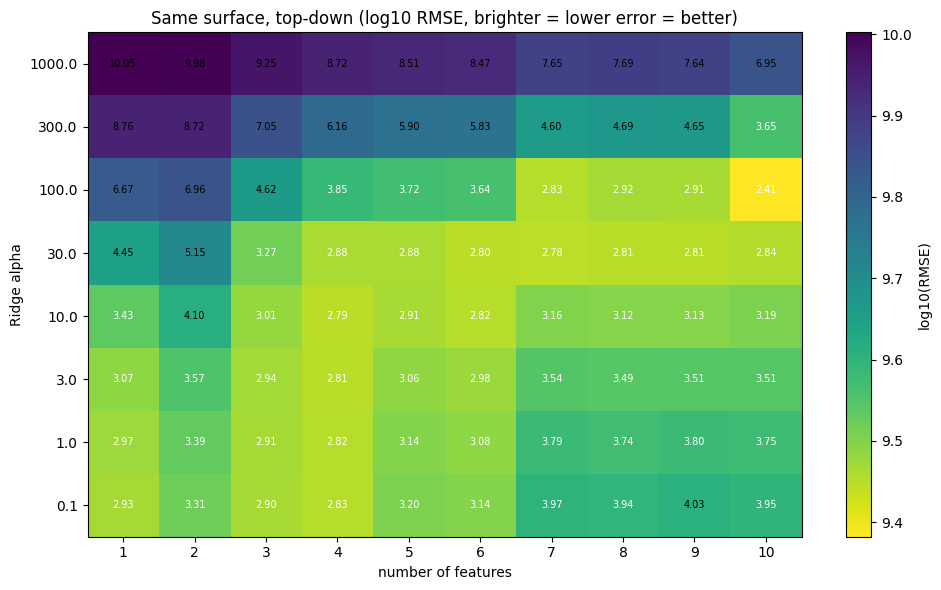

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(np.log10(pivot.values), aspect="auto", cmap="viridis_r", origin="lower")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("number of features")
ax.set_ylabel("Ridge alpha")
ax.set_title("Same surface, top-down (log10 RMSE, brighter = lower error = better)")
fig.colorbar(im, label="log10(RMSE)")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]/1e9:.2f}", ha="center", va="center",
                color="white" if np.log10(pivot.values[i,j]) < np.log10(pivot.values).mean() else "black",
                fontsize=7)

plt.tight_layout()
plt.show()

## Findings

The bowl shape is consistent at every feature count. RMSE falls
as alpha rises from 0.1, bottoms out, then rises sharply as alpha gets
too large and the model underfits toward predicting the mean. This is
the project's central hypothesis, confirmed on its own data rather than
assumed from a paper.

The minimum shifts right as feature count grows. At 1 to 2 features, the
best alpha is tiny, around 0.1 to 1, and barely any regularization is
needed. By 10 features, the best alpha in the grid is 100, two orders of
magnitude more shrinkage required to control the extra flexibility. This
is the concrete, quantified version of the claim that more features need
more regularization, not just a qualitative one.

More features without more regularization is actively harmful. At
alpha 0.1, going from 4 features, RMSE 2.83B, to 10 features, RMSE
3.95B, makes things worse. The same 10 features at alpha 100
reach RMSE 2.41B, the best cell in the entire grid. Identical data and
identical model family. Regularization strength alone is the difference
between the worst and best outcomes at that feature count.

The best cell, 10 features and alpha 100 at RMSE 2.41B, beats
every model from Layers 0-2 and the SARIMA+Ridge blend (2.38B) - though
not SARIMAX+WSTS (2.17B, notebook 02), the actual best point estimate in
the project, which earns that ranking with one deliberately-chosen
feature and no grid-scanning at all. Flagging the capstone number clearly
regardless, it was found by scanning 80 test-window evaluations, exactly
the setup where a good-looking cell can appear by chance. It is not
proposed as a new headline model. A fair test would require picking
feature count and alpha on a validation window, the same way SARIMA's
order, Ridge's alpha, and the blend weight were chosen, then confirming
it holds on an untouched test period.

## Key takeaways

The project's central question, whether more data or features help, has
a real, self-generated answer for this series: only when regularization
scales with it. Feature count alone does not predict accuracy. Feature
count relative to regularization strength does.

This reframes every earlier layer-did-not-beat-baseline result. It was
not necessarily that the alt data lacked signal. Layers 1 and 2 used one
fixed, modest alpha of 10 rather than searching the regularization axis
properly. The surface shows the same 9 to 10 feature set can do much
better or much worse than what got reported, depending entirely on
regularization strength.

The honest next step is to pick
feature count and alpha on a validation window, then confirm on a fresh
test period, the same discipline already applied to SARIMA's order and
the blend's weight. Until that is done, 2.41B in the grid is a promising
lead, not a result.

Read as one project rather than six separate notebooks: Occam's razor
held, exactly as the case asked to keep in mind - not as an assumption
this project started with, but as a result it ended up proving on its
own data.